In [1]:
import torch
import requests
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from io import BytesIO
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
from torchvision import transforms as tfms
from diffusers import StableDiffusionPipeline, DDIMScheduler

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [2]:
def load_image(url, size=None):
    response = requests.get(url,timeout=0.2)
    img = Image.open(BytesIO(response.content)).convert('RGB')
    if size is not None:
        img = img.resize(size)
    return img

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

In [4]:
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5").to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

  0%|          | 0/50 [00:00<?, ?it/s]

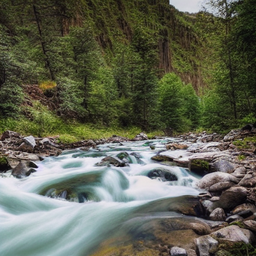

In [10]:
prompt= "A beautiful landscape with a river flowing through the mountains"
neg_prompt= "blurry, ugly, stock photo"

im= pipe(prompt, neg_prompt).images[0]
im.resize((256, 256), Image.Resampling.LANCZOS)

In [16]:
# This function represents the standard DDIM pipeline

@torch.no_grad()
def sample(prompt, start_step=0, start_latents=None,guidance_scale=3.5, num_inference_steps=30,num_images_per_prompt=1, do_classifier_free_guidance=True,negative_prompt='', device=device):

    text_embeddings = pipe._encode_prompt(prompt, device, num_images_per_prompt, do_classifier_free_guidance, negative_prompt)

    pipe.scheduler.set_timesteps(num_inference_steps, device=device)

    if start_latents is None:
        start_latents = torch.randn(1, 4, 64, 64, device=device)
        start_latents *= pipe.scheduler.init_noise_sigma

    latents = start_latents.clone()

    for i in tqdm(range(start_step, num_inference_steps)):

        t = pipe.scheduler.timesteps[i]

        latent_model_input = torch.cat([latents] * 2) if do_classifier_free_guidance else latents
        latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)

        noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=text_embeddings).sample

        if do_classifier_free_guidance:
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)


        # Normally we'd rely on the scheduler to handle the update step:
        # latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample
        # But here we will implememt it manually to update it

        prev_t = max(1, t.item() - (1000//num_inference_steps)) # t-1
        alpha_t = pipe.scheduler.alphas_cumprod[t.item()]
        alpha_t_prev = pipe.scheduler.alphas_cumprod[prev_t]
        predicted_x0 = (latents - (1-alpha_t).sqrt()*noise_pred) / alpha_t.sqrt()
        direction_pointing_to_xt = (1-alpha_t_prev).sqrt()*noise_pred
        latents = alpha_t_prev.sqrt()*predicted_x0 + direction_pointing_to_xt

    images = pipe.decode_latents(latents)
    images = pipe.numpy_to_pil(images)

    return images

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py:313: FutureWarning: `_encode_prompt()` is deprecated and it will be removed in a future version. Use `encode_prompt()` instead. Also, be aware that the output format changed from a concatenated tensor to a tuple.
  deprecate("_encode_prompt()", "1.0.0", deprecation_message, standard_warn=False)


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py:599: FutureWarning: The decode_latents method is deprecated and will be removed in 1.0.0. Please use VaeImageProcessor.postprocess(...) instead
  deprecate("decode_latents", "1.0.0", deprecation_message, standard_warn=False)


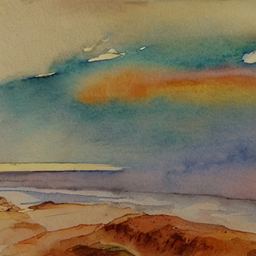

In [17]:
sample('Watercolor painting of a beach sunset', negative_prompt=neg_prompt, num_inference_steps=50)[0].resize((256, 256), Image.Resampling.LANCZOS)

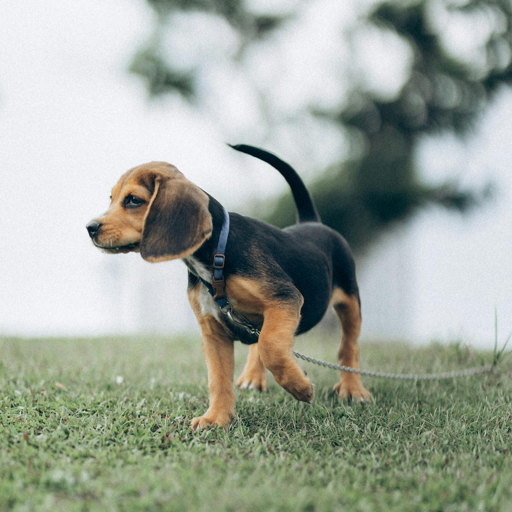

In [49]:
input_image = load_image('https://images.pexels.com/photos/8306128/pexels-photo-8306128.jpeg', size=(512, 512))
input_image_prompt = "Photograph of a puppy on the grass"
input_image

In [21]:
with torch.no_grad():
  latent = pipe.vae.encode(tfms.functional.to_tensor(input_image).unsqueeze(0).to(device)*2-1)
l = 0.18215 * latent.latent_dist.sample()

In [22]:
# This function will represent the inverse implemetation for DDIM
@torch.no_grad()
def invert(start_latents, prompt, guidance_scale=3.5, num_inference_steps=80, num_images_per_prompt=1, do_classifier_free_guidance=True, negative_prompt='', device=device):

    text_embeddings = pipe._encode_prompt(prompt, device, num_images_per_prompt, do_classifier_free_guidance, negative_prompt)

    latents = start_latents.clone()

    intermediate_latents = []

    pipe.scheduler.set_timesteps(num_inference_steps, device=device)

    timesteps = reversed(pipe.scheduler.timesteps)

    for i in tqdm(range(1, num_inference_steps), total=num_inference_steps-1):

        if i >= num_inference_steps - 1:
          continue

        t = timesteps[i]

        latent_model_input = torch.cat([latents] * 2) if do_classifier_free_guidance else latents
        latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)

        noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=text_embeddings).sample

        if do_classifier_free_guidance:
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        current_t = max(0, t.item() - (1000//num_inference_steps))
        next_t = t
        alpha_t = pipe.scheduler.alphas_cumprod[current_t]
        alpha_t_next = pipe.scheduler.alphas_cumprod[next_t]

        # Inverted update step (re-arranging the update step to get x(t) (new latents) as a function of x(t-1) (current latents)
        latents = (latents - (1-alpha_t).sqrt()*noise_pred)*(alpha_t_next.sqrt()/alpha_t.sqrt()) + (1-alpha_t_next).sqrt()*noise_pred

        intermediate_latents.append(latents)

    return torch.cat(intermediate_latents)

In [23]:
inverted_latents = invert(l, input_image_prompt, num_inference_steps=50)
inverted_latents.shape

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py:313: FutureWarning: `_encode_prompt()` is deprecated and it will be removed in a future version. Use `encode_prompt()` instead. Also, be aware that the output format changed from a concatenated tensor to a tuple.
  deprecate("_encode_prompt()", "1.0.0", deprecation_message, standard_warn=False)


  0%|          | 0/49 [00:00<?, ?it/s]

torch.Size([48, 4, 64, 64])

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py:599: FutureWarning: The decode_latents method is deprecated and will be removed in 1.0.0. Please use VaeImageProcessor.postprocess(...) instead
  deprecate("decode_latents", "1.0.0", deprecation_message, standard_warn=False)


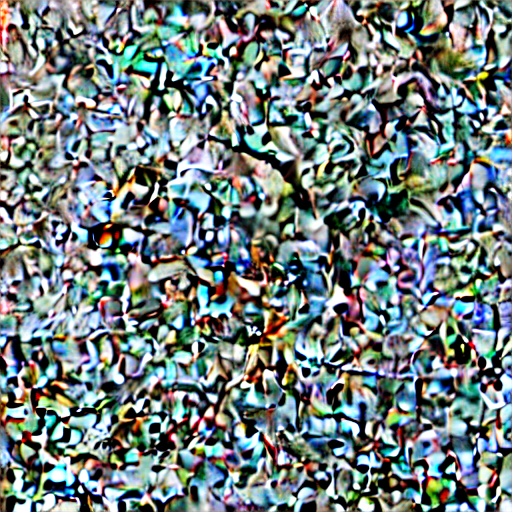

In [24]:
with torch.no_grad():
  im = pipe.decode_latents(inverted_latents[-1].unsqueeze(0))
pipe.numpy_to_pil(im)[0]

  0%|          | 0/100 [00:00<?, ?it/s]

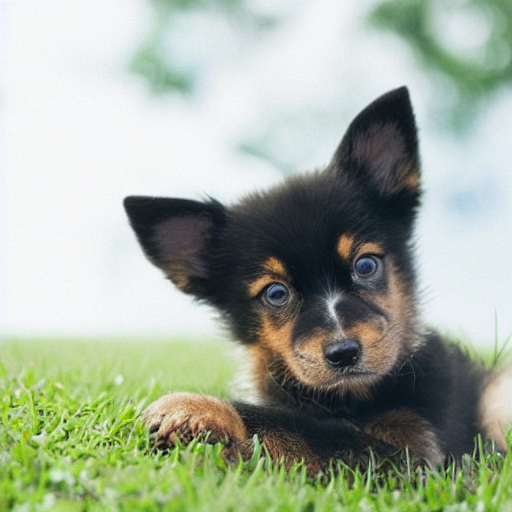

In [26]:
pipe(input_image_prompt, latents=inverted_latents[-1][None], num_inference_steps=100, guidance_scale=3.5).images[0]
# Here, the output is not the same as the original input image

  0%|          | 0/30 [00:00<?, ?it/s]

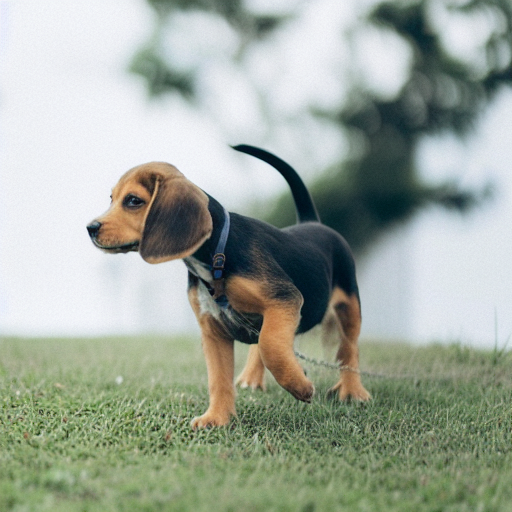

In [29]:
start_step = 20
sample(input_image_prompt, start_latents=inverted_latents[-(start_step+1)][None], start_step=start_step, num_inference_steps=50)[0]

  0%|          | 0/30 [00:00<?, ?it/s]

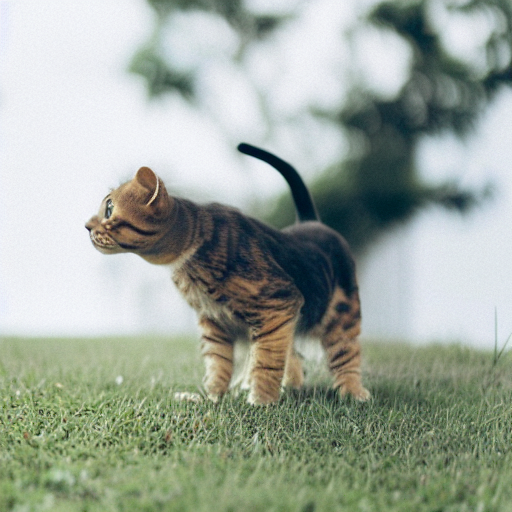

In [37]:
start_step = 20
new_prompt = input_image_prompt.replace('puppy', 'cat')
sample(new_prompt, start_latents=inverted_latents[-(start_step+1)][None], start_step=start_step, num_inference_steps=50)[0]
# The output is similar to input image with only puppy being replaced by a cat because of start_step

  0%|          | 0/30 [00:00<?, ?it/s]

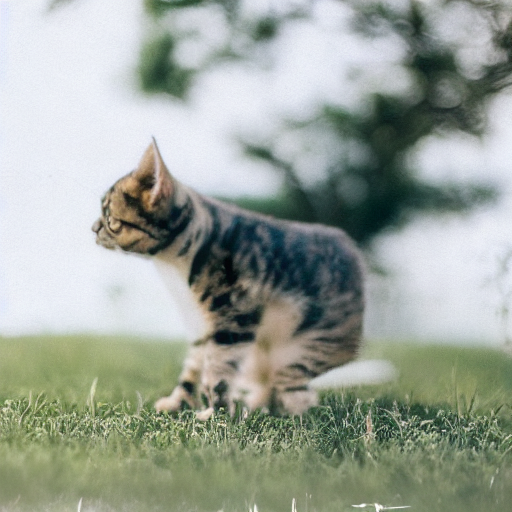

In [39]:
start_step = 20
num_inference_steps = 50
pipe.scheduler.set_timesteps(num_inference_steps)
noisy_l = pipe.scheduler.add_noise(l, torch.randn_like(l), pipe.scheduler.timesteps[start_step])
sample(new_prompt, start_latents=noisy_l, start_step=start_step, num_inference_steps=num_inference_steps)[0]
# This output is not as accurate without inversion process (This uses img2img)


In [40]:
# a simplified function for DDIM inversion
def edit(input_image, input_image_prompt, edit_prompt, num_steps=100, start_step=30, guidance_scale=3.5):
    with torch.no_grad():
      latent = pipe.vae.encode(tfms.functional.to_tensor(input_image).unsqueeze(0).to(device)*2-1)
    l = 0.18215 * latent.latent_dist.sample()
    inverted_latents = invert(l, input_image_prompt, num_inference_steps=num_steps)
    final_im = sample(edit_prompt, start_latents=inverted_latents[-(start_step+1)][None],start_step=start_step, num_inference_steps=num_steps, guidance_scale=guidance_scale)[0]
    return final_im

  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

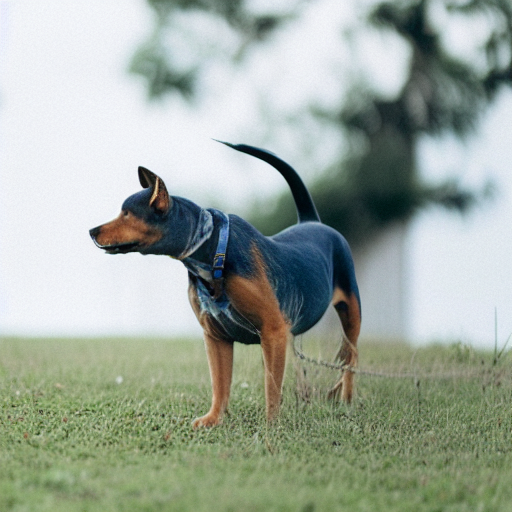

In [51]:
edit(input_image, 'A puppy on the grass', 'an old blue dog on the grass', num_steps=50, start_step=10)

  0%|          | 0/149 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

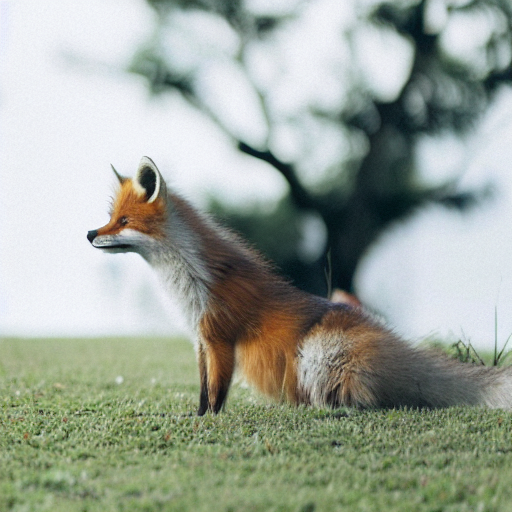

In [57]:
edit(input_image, input_image_prompt, "A furry fox on the grass", num_steps= 150, start_step= 30, guidance_scale= 3.5)

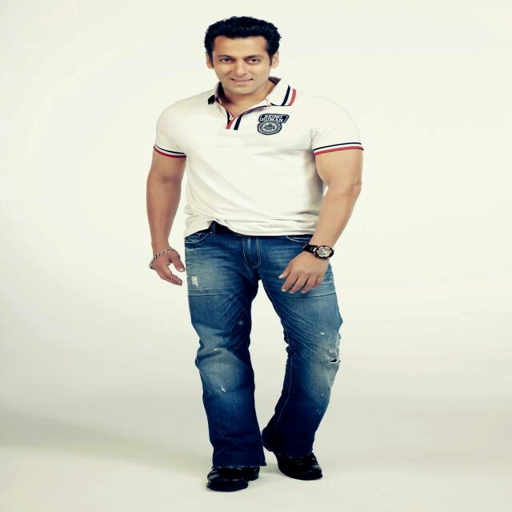

In [54]:
face = load_image('https://i.pinimg.com/736x/49/9b/52/499b525e56bcd901e63f2ca568f10d89.jpg', size=(512, 512))
face

  0%|          | 0/149 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

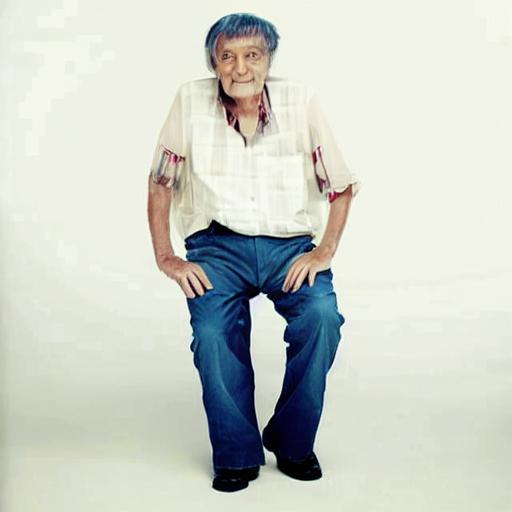

In [56]:
edit(face, "A photo of a man", "A photo of an old man", num_steps=150, start_step=30, guidance_scale=3.5)